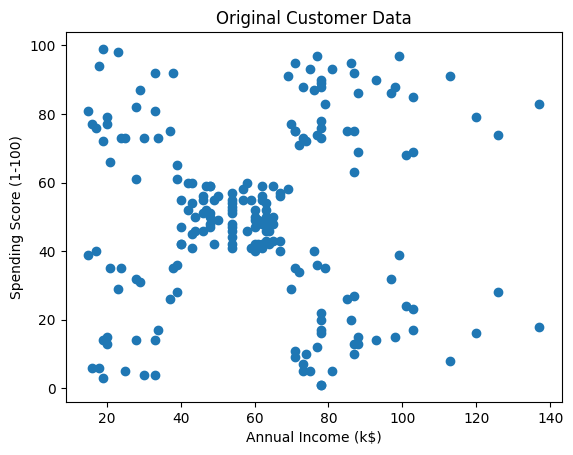

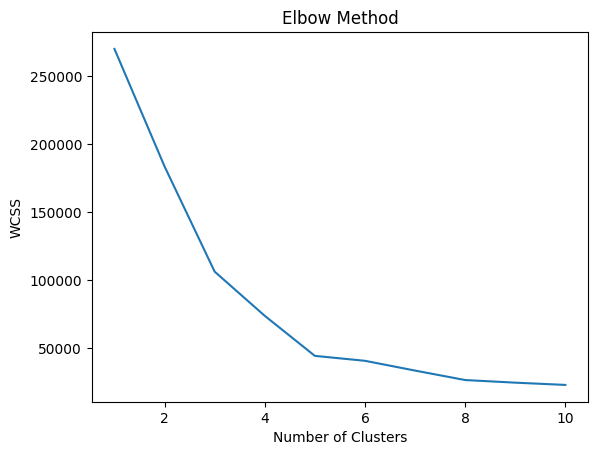

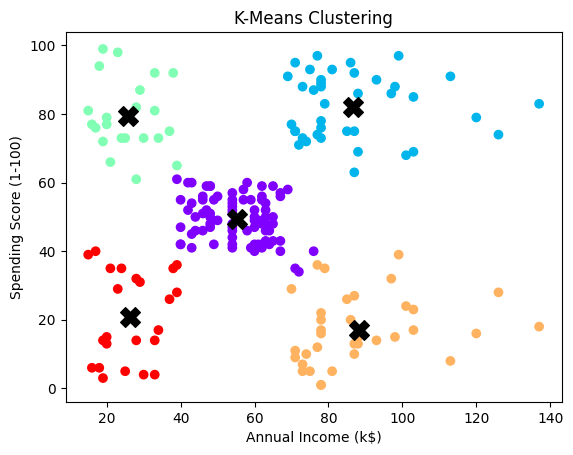

In [ ]:
# ==============================
# K-MEANS - Mall Customer Dataset
# ==============================

# Step 1: Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Step 2: Load Dataset
data = pd.read_csv("Mall_Customers.csv")

# Step 3: Select Features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Step 4: Visualize Original Data
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'])
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Original Customer Data")
plt.show()

# Step 5: Decide Number of Clusters using Elbow Method
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# Assume K = 5 (commonly chosen after elbow graph)
k = 5

# Step 6: Create KMeans Model
kmeans = KMeans(n_clusters=k, random_state=42)

# Step 7: Fit the Model
kmeans.fit(X)

# Step 8: Get Cluster Labels
labels = kmeans.labels_

# Step 9: Get Centroids
centroids = kmeans.cluster_centers_

# Step 10: Plot Clustered Data
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels, cmap='rainbow')
plt.scatter(centroids[:, 0], centroids[:, 1],
            s=200, c='black', marker='X')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means Clustering")
plt.show()

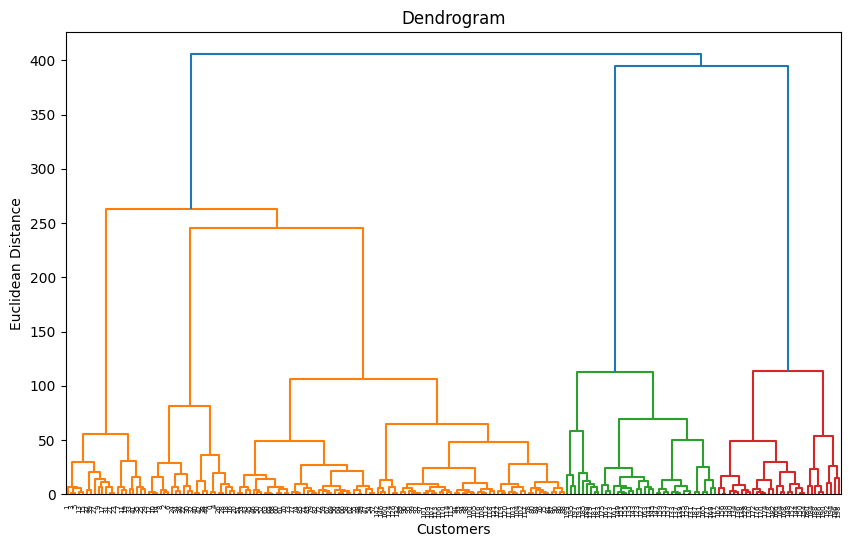

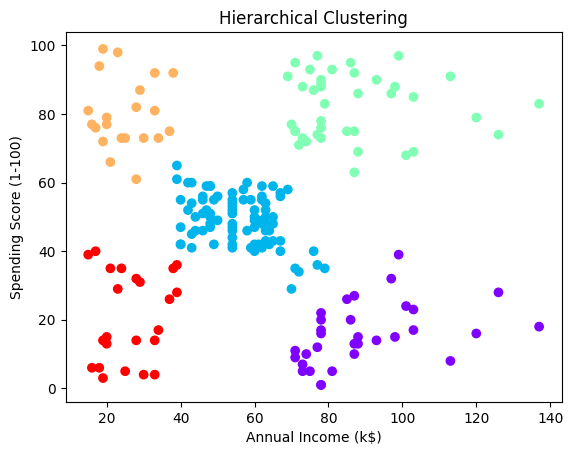

In [ ]:
# ===================================
# HIERARCHICAL CLUSTERING - Mall Dataset
# ===================================

# Step 1: Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

# Step 2: Load Dataset
data = pd.read_csv("Mall_Customers.csv")

# Step 3: Select Same Features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Step 4: Generate Linkage Matrix
linked = linkage(X, method='ward')

# Step 5: Plot Dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()

# Assume number of clusters = 5 (after cutting dendrogram)
n_clusters = 5

# Step 6: Create Agglomerative Model
hc = AgglomerativeClustering(n_clusters=n_clusters)

# Step 7: Fit and Predict Labels
labels = hc.fit_predict(X)

# Step 8: Plot Clustered Data
plt.scatter(X.iloc[:, 0], X.iloc[:, 1],
            c=labels, cmap='rainbow')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Hierarchical Clustering")
plt.show()